<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day1/ExerciseXP/Exercises_XP_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **content on the platform**. Some cells are **prefilled** and must be **executed only**. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

**Learning points** appear when a concept is important for intuition or to help you learn new tricks/concepts related to other AI topics.


## Objectives

**What you will learn**  
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**  
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.


## 🌟 Exercise 1: Small Quiz
-What is the key difference between traditional machine learning and deep learning?

Traditional machine learning relies on manual feature engineering and shallower algorithms, whereas deep learning automatically learns hierarchical feature representations directly from raw data using deep artificial neural networks.Concrete Example: In computer vision, traditional ML requires humans to design edge-detectors (like SIFT), whereas deep learning extracts patterns directly from raw pixels.

How do artificial neural networks mimic the human brain?

They use interconnected computational nodes ("neurons") arranged in layers, where each connection passes a signal multiplied by an adjustable weight, resembling biological synapses that strengthen or weaken based on experience.

Why does deep learning perform better on large datasets compared to traditional machine learning?

Traditional machine learning models saturate in performance once a certain amount of data is reached because of their limited capacity, while deep neural networks scale continuously due to their massive parameter volume and ability to capture highly complex non-linear combinations.

What are some challenges of deep learning, and how can they be addressed?

Major challenges include overfitting and extreme computational expense. They can be addressed by implementing regularization (dropout, weight decay), gathering more data, using data augmentation, and leveraging hardware accelerators like GPUs/TPUs.

What is feature engineering, and why is it not needed in deep learning?

Feature engineering is the manual process of transforming raw data into informative variables using domain expertise. It is not required in deep learning because the hidden layers automatically discover and extract the optimal features through representation learning during training.

What role do hidden layers play in a deep learning model?

Hidden layers act as feature extractors that progressively map low-level raw inputs into increasingly abstract, high-level structural representations.Concrete Example: In facial recognition, the first hidden layer detects edges, the second combines edges into shapes (eyes, noses), and deeper layers recognize full facial structures.

In an artificial neural network, what is the function of an activation function?

An activation function introduces non-linearity into the network, allowing the model to learn and represent complex geometric decision boundaries instead of just straight lines.




## 🌟 Exercise 2: Building a Simple Perceptron Decision System

**As stated in the instructions**  
You will create a perceptron-based decision system to decide whether you should go outside based on two inputs:
- Temperature in °F
- Rainy where Yes is 1 and No is 0

Given parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2. Compute the weighted sum
\[ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} \]
Apply a step activation:
- If Weighted Sum > 20, output 1
- If Weighted Sum \le 20, output 0

Evaluate:  
Case 1: Temperature 70°F, Rain 0  
Case 2: Temperature 50°F, Rain 1

**Guidance**  
Implement the weighted sum function yourself. Use a reusable step activation. Then compute the two cases and print the decision for each.

**Learning point**  
A perceptron implements a linear decision boundary. The bias shifts the threshold. Use step activation for simple binary rules. Prefer differentiable activations when training with gradient descent.

![image.png](https://github.com/user-attachments/assets/3c4f3261-164d-4039-8e1c-aff2db7162dd)


In [2]:
# PREFILLED: juste exécuter
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0


# To-Do: implement weighted_sum then use it to compute the two cases
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    # Remplacement du 'pass' par la formule mathématique demandée
    return (W_TEMP * temperature_f) + (W_RAIN * rain01) + BIAS


# Calcul des deux cas d'études
case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})


{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}


Yes, the perceptron suggests going outside in both cases (decision = 1)

.Case 1: The weighted sum is 44.0 (\(0.6 \times 70 + 0.4 \times 0 + 2.0\)), which is greater than the threshold of 20

.Case 2: The weighted sum is 32.4 (\(0.6 \times 50 + 0.4 \times 1 + 2.0\)), which also clears the threshold of 20.

According to the threshold rule, any weighted sum strictly greater than 20 results in an output of 1. The bias of 2.0 acts as a baseline shift that increases the overall weighted sum, making it easier for both scenarios to cross the required threshold of 20 and trigger a positive decision to go outside.


## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow or Keras

**As stated in the instructions**  
Build a classifier for MNIST with:
- One input layer
- One hidden layer with 128 neurons and ReLU activation
- One output layer with 10 neurons and softmax activation

Steps:
1. Import TensorFlow and needed modules from `tensorflow.keras`
2. Load the MNIST dataset
3. Normalize data by dividing by 255.0
4. One-hot encode the labels
5. Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
6. Compile with optimizer `adam`, loss `categorical_crossentropy`, metrics `accuracy`
7. Train and evaluate on the test set

**Guidance**  
You will execute prefilled boilerplate for imports and dataset loading. You will complete the one-hot encoding and the model specification, compile, train, and evaluate.

**Learning point**  
Normalization stabilizes optimization. One-hot encoding matches softmax outputs to target vectors. ReLU accelerates training by avoiding saturation, while softmax maps logits to a probability simplex.

![image.png](https://github.com/user-attachments/assets/61737b80-69cb-41a1-aea5-76092cd2a373)


In [5]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [6]:
# To-Do: one-hot encode labels y_train and y_test using to_categorical
# Hints: use to_categorical
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)


Labels one-hot: (60000, 10) (10000, 10)


In [7]:
# To-Do:  Build a sequential model with Flatten, Dense(128, ReLU), Dense(10, softmax)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# To-Do: compile the model with adam, categorical_crossentropy, and accuracy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
# To-Do: train then evaluate
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1)
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9221 - loss: 0.2763 - val_accuracy: 0.9593 - val_loss: 0.1400
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9648 - loss: 0.1211 - val_accuracy: 0.9733 - val_loss: 0.0933
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9742 - loss: 0.0834 - val_accuracy: 0.9727 - val_loss: 0.0976
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9810 - loss: 0.0621 - val_accuracy: 0.9765 - val_loss: 0.0826
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0477 - val_accuracy: 0.9780 - val_loss: 0.0757
{'test_loss': 0.07801064103841782, 'test_acc': 0.9763000011444092}


## 🌟 Exercise 4: Forward Propagation Calculation

**As stated in the instructions**  
Predict house prices given:
- Inputs: x₁ = 2000 square feet, x₂ = 3 bedrooms
- Weights: w₁ = 0.5, w₂ = 0.7
- Bias: b = 50,000
- Activation: ReLU

Compute z before activation, apply ReLU, and interpret the prediction.

**Guidance**  
Write scalar computations. Then reason about the role of the bias and ReLU on the output scale.

**Learning point**  
ReLU passes positive linear combinations unchanged and zeros out negatives. Bias sets the baseline prediction independent of inputs.
![](./figs/1.gif)

In [10]:
# To-Do: compute forward propagation for the given numbers
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# To-Do: compute z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# To-Do: apply ReLU
y = max(0.0, z) #Hint: ReLU acts like max functions and leaves only positive outputs

print({"z": z, "prediction": y})


{'z': 51002.1, 'prediction': 51002.1}


The result of the prediction represents a predicted house price of $51,002.10.
Because the calculated net input \(z\) is positive, the non-linear ReLU activation function leaves it completely unchanged, passing the exact value forward.
 The target output is heavily influenced by the bias of $50,000, which establishes a fixed baseline price for any property before accounting for its structural features.
  Furthermore, due to the difference in input scaling, the square footage feature dominates the variable portion of the price computation ($1,000.00), while the bedroom feature has a negligible impact ($2.10) because its raw numerical value is significantly smaller.

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

**As stated in the enoncé**  
You will code a simple neural network that performs forward propagation and backpropagation for a regression problem predicting exam scores from study hours.

**Guidance**  
Run the prefilled code. Then modify the learning rate or initial weights and observe changes in the loss and updates.
Provide a short written explanation.

**Learning point**  
Gradient descent updates parameters in the direction of steepest loss reduction.
The learning rate controls step size. Too small slows learning. Too large risks divergence.


In [11]:
# PREFILLED: just execute
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)


Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


Updating weights using gradient descent reduces the prediction error because it calculates the partial derivatives (gradients) of the loss function with respect to each parameter.
These gradients point in the direction of the steepest increase in error, so subtracting them from the current weights and bias forces the model to move in the exact opposite direction toward the global minimum.If we modify the initial weights to values closer to the objective, the initial loss decreases immediately.
 Furthermore, increasing the learning rate (e.g., changing learning_rate from 0.01 to 0.05) speeds up the convergence process by taking larger steps toward the minimum, but if we set it too high, the updates will overshoot the target and cause the loss to diverge. Conversely, decreasing the learning rate makes learning much more stable but requires significantly more iterations to minimize the error.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

**As stated in the enoncé**  
Train a simple model on MNIST, then visualize predictions for some test images with predicted labels.

**Guidance**  
Reuse the model from Exercise 3 if still in memory. Otherwise re-run Exercise 3. Plot a grid of test images with predicted labels and optionally true labels.

**Learning point**  
Softmax outputs are probabilities over classes. Inspect the confidence values. Visual errors often indicate confusions between similar digits.

![image.png](https://github.com/user-attachments/assets/e00d3913-55d4-4b62-8f70-1216bcc2e4e4)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


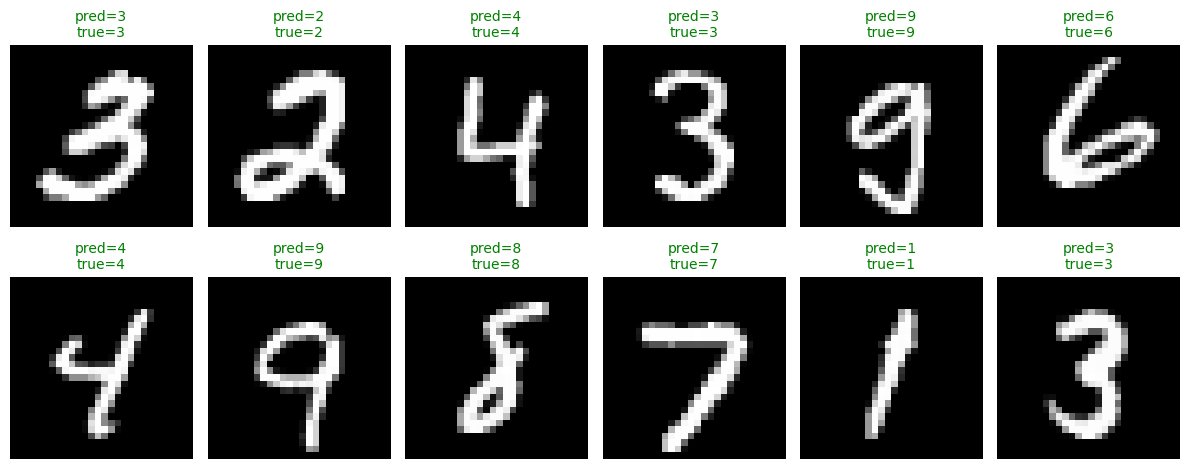

In [12]:
# To-Do: visualize a few predictions with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Ensure we have the model and x_test, y_test from Exercise 3
# To-Do: select N samples from x_test by using np.random.choice
num_samples = 12
idx = np.random.choice(len(x_test), size=num_samples, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# To-Do: get predictions
y_prob = model.predict(x_vis)
y_pred = np.argmax(y_prob, axis=1)

# plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2.5*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")

    # Vert si la prédiction est correcte, Rouge si elle est fausse
    color = "green" if y_pred[i-1] == y_true[i-1] else "red"
    plt.title(f"pred={y_pred[i-1]}\ntrue={y_true[i-1]}", color=color, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()
